In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
# Load the dataset 



In [24]:
data = pd.read_csv('ventas_ml_clase2.csv')
display(data.head())


,marketing,precio,temporada,tienda,canal,ventas
0,5548.49,25.74,2,Sur,Tienda,461.70
1,3128.03,31.60,3,Occidente,Tienda,229.12
2,6350.81,37.94,3,Centro,Tienda,397.16
3,6693.02,34.28,3,Norte,Tienda,458.31
4,1488.14,30.45,1,Occidente,Tienda,197.70


In [25]:
print("""
Filas: {}, Columnas: {}
""".format(data.shape[0], data.shape[1]))

print("""Tipos de datos:
{}
""".format(data.dtypes))    


Filas: 1200, Columnas: 6

Tipos de datos:
marketing    float64
precio       float64
temporada      int64
tienda        object
canal         object
ventas       float64
dtype: object



In [26]:
data.describe(include='all').transpose().head()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
marketing,1200.0,NaN,NaN,NaN,4961.787167,1768.35789,0.0,3772.115,5006.215,6107.785,10721.94
precio,1200.0,NaN,NaN,NaN,34.560042,7.154758,13.55,29.915,34.91,39.245,55.4
temporada,1200.0,NaN,NaN,NaN,2.5125,1.112449,1.0,2.0,3.0,3.0,4.0
tienda,1200,5,Norte,269,NaN,NaN,NaN,NaN,NaN,NaN,NaN
canal,1200,3,Tienda,702,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
# Predecir las ventaas usando vaiables precio y temporada, tienda, canal
X = data[['marketing', 'precio', 'temporada', 'tienda', 'canal']]  # Features
y = data['ventas']  # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Tamaño del conjunto de entrenamiento: {}, Tamaño del conjunto de prueba: {} \n Porcentaje de prueba: {:.2f}%".format(X_train.shape[0], X_test.shape[0], (X_test.shape[0] / X.shape[0]) * 100))


# Define the preprocessing for categorical features
categorical_features = ['temporada', 'tienda', 'canal']
categorical_transformer = OneHotEncoder(drop='first')
# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'  # Keep the 'precio' column as is
)
# Create a pipeline that combines preprocessing and the regression model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
# Train the model
pipeline.fit(X_train, y_train)
# Make predictions
y_pred = pipeline.predict(X_test)
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')
print(f'Mean Absolute Error: {mae}')
pipeline


Tamaño del conjunto de entrenamiento: 960, Tamaño del conjunto de prueba: 240 
 Porcentaje de prueba: 20.00%
Mean Squared Error: 2024.923814033733
R^2 Score: 0.6574270702065037
Mean Absolute Error: 36.13661188590941


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

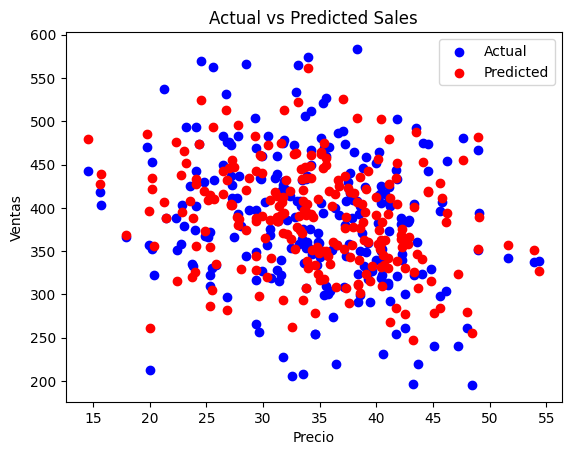

In [38]:

# draw the regression line 
import matplotlib.pyplot as plt
plt.scatter(X_test['precio'], y_test, color='blue', label='Actual')
plt.scatter(X_test['precio'], y_pred, color='red', label='Predicted')
plt.xlabel('Precio')
plt.ylabel('Ventas')
plt.title('Actual vs Predicted Sales')
plt.legend()
plt.show()